# Сортировка мусора

Детекция пластиковых бутылок и других объектов на ленте конвейере

In [1]:
# pip install torchmetrics[detection]

In [33]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager

from sklearn.model_selection import train_test_split

from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision.transforms import v2
from torchvision import models, datasets
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchmetrics.detection.iou import IntersectionOverUnion
from torchinfo import summary

In [ ]:
# boxes = box_convert(boxes, in_fmt='xywh', out_fmt='xyxy')

In [3]:
class Ansi:
    green = '\033[32m'
    red = '\033[31m'
    bold = '\033[1m'
    underline = '\033[4m'
    end = '\033[0m'

In [4]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

EPOCHS = 25
BATCH_SIZE = 2

PATH = Path('../../Documents/datasets/waste_detection')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch use: {Ansi.green}{Ansi.bold}{DEVICE}{Ansi.end}', 
      f'({torch.cuda.get_device_name()})' 
      if torch.cuda.is_available() else '')

torch use: cuda (AMD Radeon RX 7800 XT)


## Load data

In [5]:
train_data = pd.read_csv(PATH.joinpath('train.csv'))
test_data = pd.read_csv(PATH.joinpath('test.csv'))

sample_submission = pd.read_csv(PATH.joinpath('sample_submission.csv'))

img_path = PATH.joinpath('images')

In [6]:
train_data.head()

,file_name,bbox,category_id
0,000001.jpg,"[840.0, 0.0, 176.0, 124.0]",4.0
1,000001.jpg,"[612.0, 306.0, 383.0, 397.0]",2.0
2,000001.jpg,"[990.92, 551.0, 105.00000000000011, 186.0]",4.0
3,000002.jpg,"[1000.0, 614.0, 98.0, 178.0]",4.0
4,000002.jpg,"[605.0, 358.0, 402.0, 409.0]",2.0


In [7]:
test_data.head()

,file_name
0,000003.jpg
1,000006.jpg
2,000013.jpg
3,000016.jpg
4,000019.jpg


In [8]:
sample_submission.head()

,file_name,bbox
0,000003.jpg,"[[5.0, 0.64, 536.1, 76.56, 834.52, 890.82], [5..."
1,000006.jpg,"[[4.0, 0.91, 397.68, 3.2, 218.05, 970.42], [4...."
2,000013.jpg,[]
3,000016.jpg,"[[8.0, 0.89, 587.89, 771.75, 636.26, 337.43], ..."
4,000019.jpg,"[[7.0, 0.68, 75.08, 220.41, 982.22, 794.76], [..."


In [9]:
idx_to_class = {
    1: 'PET (transparent) (green)',
    2: 'PET (transparent) (brown)',
    3: 'PET (transparent) (blue)',
    4: 'PET (transparent)',
    5: 'PET (transparent) (dark blue)',
    6: 'PET (black)',
    7: 'PET (white)',
    8: 'PET (sticker)',
    9: 'PET (flacon)',
    10: 'PET (household chemicals)',
    11: 'PND (household chemicals)',
    12: 'PND packet',
    13: 'Other plastic',
    14: 'Other plastic (transparent)',
    15: 'Not plastic'
}

In [10]:
annotations = {}

for _, row in train_data.iterrows():
    file_name = row['file_name']
    category_id = row['category_id']

    if file_name not in annotations:
        annotations[file_name] = {'boxes': [], 'labels': []}
    if not np.isnan(category_id):
        # Преобразуем строку в список
        bbox = ast.literal_eval(row['bbox'])
        # [x_left, y_top, width, height] --> [x_min, y_min, x_max, y_max]
        bbox[2] = bbox[2] + bbox[0]
        bbox[3] = bbox[3] + bbox[1]
        annotations[file_name]['boxes'].append(bbox)
        annotations[file_name]['labels'].append(int(category_id))


img_names = list(annotations.keys())

In [11]:
train_img, val_img = train_test_split(img_names, test_size=.2, random_state=SEED)

test_img = test_data['file_name'].tolist()

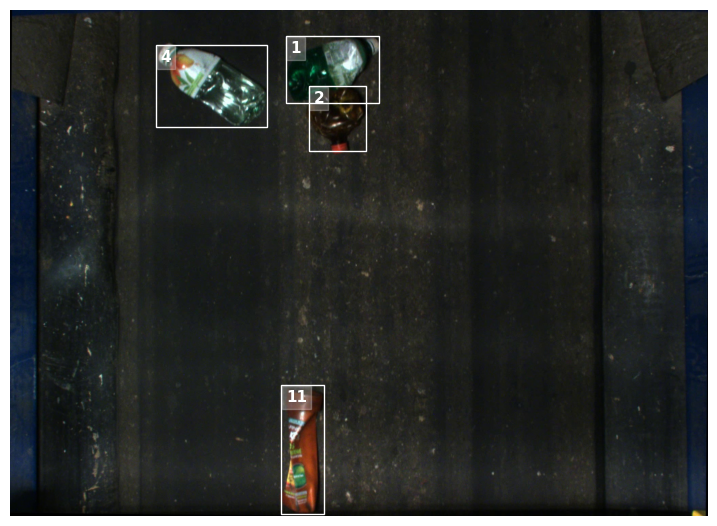

In [95]:
def _bbox_and_label(ax, boxes, labels, box_color='white'):
    
    for box, label in zip(boxes, labels):
        # Координаты рамки
        x_min, y_min, x_max, y_max = box

        # Добавить рамку
        rect = patches.Rectangle(
            (x_min, y_min),  # Левый верхний угол
            x_max - x_min,   # Ширина
            y_max - y_min,   # Высота
            linewidth=1,
            edgecolor=box_color,
            facecolor='none',
        )
        ax.add_patch(rect)

        # Добавить подпись
        # class_name = idx_to_class[label]
        class_name = label
        ax.text(
            x_min + 14,
            y_min + 14,
            class_name,
            color=box_color,
            fontsize=11,
            fontweight='bold',
            backgroundcolor=box_color,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=dict(facecolor='white', pad=3, alpha=.25, edgecolor=box_color),
        )


def plot_bounding_boxes(img_name, annotations, pred_boxes=None, pred_labels=None):
    image = Image.open(PATH.joinpath('images', image_name))
    boxes = annotations[image_name]['boxes']
    labels = annotations[image_name]['labels']

    
    fig, ax = plt.subplots(1, figsize=(9, 9))
    ax.imshow(image)

    _bbox_and_label(ax, boxes, labels)

    if pred_boxes is not None and pred_labels is not None:
        _bbox_and_label(ax, pred_boxes, pred_labels, box_color='red')

    
    ax.axis('off')
    plt.show()


image_name = '006638.jpg'
image_name = np.random.choice(img_names)

plot_bounding_boxes(image_name, annotations)

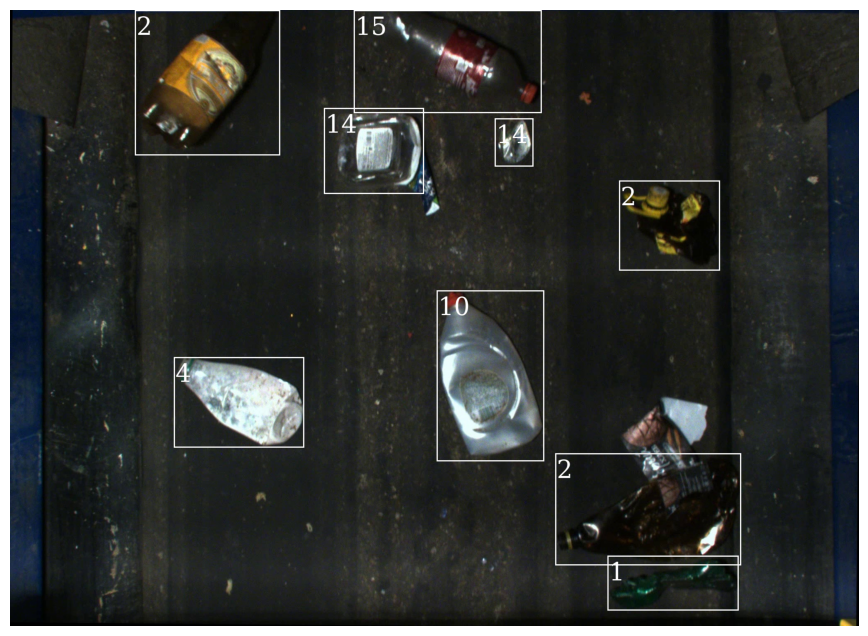

In [36]:
image_name = '006638.jpg'
# image_name = np.random.choice(img_names)
image = Image.open(PATH.joinpath('images', image_name))
image = v2.functional.to_image(image)

boxes = torch.tensor(annotations[image_name]['boxes'])
# boxes = box_convert(boxes, in_fmt='xywh', out_fmt='xyxy')
labels = annotations[image_name]['labels']
# labels_cls = [idx_to_class[idx] for idx in labels]
labels_cls = [str(idx) for idx in labels]


bounding_boxes_image = v2.functional.to_pil_image(
    draw_bounding_boxes(
        image, 
        boxes, 
        labels_cls,
        colors='#ffffff',
        width=3,
        font=font_manager.findSystemFonts(fontext='ttf')[1],
        font_size=60
    ))

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(bounding_boxes_image)
ax.axis('off')
plt.show()

In [13]:
class CustomDataset(Dataset):
    def __init__(self, path, img_names, annotations=None, transform=None):
        self.path = path
        self.img_names = img_names
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = img_names[idx]
        img = Image.open(self.path.joinpath(img_name)).convert('RGB')

        if self.transform:
            img = self.transform(img)

        if self.annotations is None:
            return img

        boxes = self.annotations[img_name]['boxes']
        labels = self.annotations[img_name]['labels']
        target = {
            # При отсутствии аннотаций reshape(-1, 4) 
            # автоматически создаёт пустой тензор правильной формы.
            'boxes': torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

        return img, target

In [14]:
train_transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])

test_transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])


train_set = CustomDataset(img_path, train_img, annotations, transform=train_transform)
val_set = CustomDataset(img_path, val_img, annotations, transform=test_transform)
test_set = CustomDataset(img_path, test_img, transform=test_transform)

In [15]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
    weights='FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1'
).to(DEVICE)

In [17]:
optimizer = optim.SGD(model.parameters(), lr=.005, momentum=.9)
metric = MeanAveragePrecision().to(DEVICE)

In [18]:
for epoch in range(EPOCHS):
    
    train_loss = []
    model.train()

    loop = tqdm(train_loader)
    for images, targets in loop:
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

        train_loss.append(losses.item())

        
        loop_description = f"Epoch [{epoch + 1}/{EPOCHS}], train_loss: {np.mean(train_loss):.4f}"
        loop.set_description(loop_description)


  0%|          | 0/2400 [00:00<?, ?it/s]

/home/lake/anaconda3/envs/lime311/lib/python3.11/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


KeyboardInterrupt: 

In [22]:
model.eval()
metric.reset()  # Сбрасываем метрику перед валидацией

with torch.no_grad():
    for images, targets in tqdm(val_loader):  # val_loader — DataLoader для валидации
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Предсказания модели
        outputs = model(images)
        break

        # Подсчёт метрики (предсказания и таргеты)
        metric.update(outputs, targets)

# Вычисление итоговой метрики
val_map = metric.compute()
print(f"Validation mAP: {val_map['map']:.4f}")

  0%|          | 0/601 [00:00<?, ?it/s]

Validation mAP: -1.0000


/home/lake/anaconda3/envs/lime311/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MeanAveragePrecision was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)  # noqa: B028


In [23]:
outputs

[{'boxes': tensor([[ 605.1635,  317.1357,  997.9009,  688.3088],
          [ 856.1946,    1.3461,  991.0243,  117.1548],
          [1001.0930,  555.2949, 1089.0254,  704.2647],
          [1003.8287,  560.3091, 1090.6570,  725.8496],
          [ 854.6589,   11.3305, 1002.1277,  119.3757],
          [1011.4646,  675.9722, 1067.5175,  729.1766],
          [1001.8267,  556.1113, 1091.3142,  720.5618]], device='cuda:0'),
  'labels': tensor([ 2,  4, 14,  4, 14,  4, 15], device='cuda:0'),
  'scores': tensor([0.9814, 0.8419, 0.6078, 0.4990, 0.3559, 0.0592, 0.0538],
         device='cuda:0')},
 {'boxes': tensor([[ 601.5469,  378.1055, 1005.3186,  765.3283],
          [ 837.1439,    2.0489,  996.8224,  173.2729],
          [1002.3616,  614.7270, 1091.7513,  780.2504],
          [ 833.1060,    2.6378,  999.0104,  180.2739],
          [1006.2755,  620.2917, 1089.0873,  778.8157],
          [1003.8038,  617.2878, 1093.3195,  784.4988],
          [ 838.8273,    1.3261, 1006.1439,  168.6877],
       

In [26]:
val_img[1]

'005865.jpg'

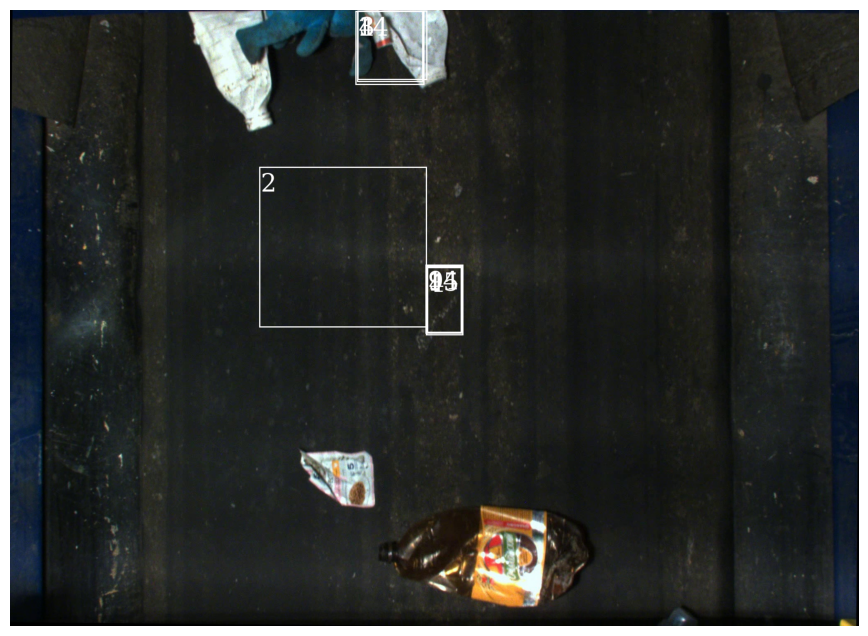

In [27]:
image_name = '005865.jpg'
image = Image.open(PATH.joinpath('images', image_name))
image = v2.functional.to_image(image)

boxes = torch.tensor([[ 601.5469,  378.1055, 1005.3186,  765.3283],
          [ 837.1439,    2.0489,  996.8224,  173.2729],
          [1002.3616,  614.7270, 1091.7513,  780.2504],
          [ 833.1060,    2.6378,  999.0104,  180.2739],
          [1006.2755,  620.2917, 1089.0873,  778.8157],
          [1003.8038,  617.2878, 1093.3195,  784.4988],
          [ 838.8273,    1.3261, 1006.1439,  168.6877],
          [1004.7692,  614.7765, 1093.2522,  784.9300]])
# boxes = box_convert(boxes, in_fmt='xywh', out_fmt='xyxy')
labels = [ 2,  4, 14, 14,  4, 15,  3,  9]
# labels_cls = [idx_to_class[idx] for idx in labels]
labels_cls = [str(idx) for idx in labels]


bounding_boxes_image = v2.functional.to_pil_image(
    draw_bounding_boxes(
        image, 
        boxes, 
        labels_cls,
        colors='#ffffff',
        width=3,
        font=font_manager.findSystemFonts(fontext='ttf')[1],
        font_size=60
    ))

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(bounding_boxes_image)
ax.axis('off')
plt.show()

## submission

In [ ]:
predictions = []

model.eval()
with torch.no_grad():
    for images, targets in tqdm(val_loader):  # val_loader — DataLoader для валидации
        images = list(image.to(DEVICE) for image in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # Предсказания модели
        outputs = model(images)